In [1]:
import warnings
warnings.filterwarnings("ignore")
import json
import requests
import torch
import numpy as np
import pandas as pd
import h5py
import os
import sys
sys.path.append("..")
from utils.balanced_builders_hdf import *
from models.autoencoder_classifier import *
from final_pipline.similarity_latent import *
from data_cleaning.data_cleaning_wavelength import *
from final_pipline.latent_similarty_funcs import *
from final_pipline.external_testset import *
from config import *
from final_pipline.hybrid_inference import *
import h5py
from Composition.run_experiment import *
from Composition.query_composition import *
from final_pipline.full_inference import *
from final_pipline.output_table import *

### Loading CS Models and Dataset

In [2]:
cs = build_balanced_cs_loaders_from_h5(
    h5_path=xrd_dataset,
    per_class_cs=105000,   
    batch_size=256,
    val_split=0.1,
    test_split=0.1,
    seed=42,
    num_workers=4,
)
print(cs["counts"])
print(cs["sizes"])  

{'triclinic': 105000, 'monoclinic': 105000, 'orthorhombic': 105000, 'tetragonal': 105000, 'trigonal': 105000, 'hexagonal': 105000, 'cubic': 105000}
{'train': 588000, 'val': 73500, 'test': 73500}


In [3]:
# --------------------------------------------------
# Load data
# --------------------------------------------------

balanced_ids = np.load(balanced_ids, allow_pickle=True)
ids = np.load(ids_gaussian_new, allow_pickle=True)
compositions = np.load(comp_path, allow_pickle=True)
crystal_systems = np.load(cs_path , allow_pickle=True)
labels = np.load(sg_path, allow_pickle=True)

# --------------------------------------------------
# Align balanced dataset
# --------------------------------------------------

id_to_index = {id_: i for i, id_ in enumerate(ids)}

balanced_indices = np.array(
    [id_to_index[id_] for id_ in balanced_ids],
    dtype=np.int64
)

compositions_balanced = compositions[balanced_indices]
ids_balanced = ids[balanced_indices]
labels_balanced = labels[balanced_indices]
balanced_cs = crystal_systems[balanced_indices]

# --------------------------------------------------
# Remove duplicate compositions
# --------------------------------------------------

_, unique_indices = np.unique(
    compositions_balanced,
    return_index=True
)

compositions_balanced = compositions_balanced[unique_indices]
ids_balanced = ids_balanced[unique_indices]
labels_balanced = labels_balanced[unique_indices]
balanced_cs = balanced_cs[unique_indices]

# --------------------------------------------------
# Build metadata dictionary
# --------------------------------------------------

id_to_metadata = {
    real_id: {
        "composition": comp,
        "space_group": int(sg),
        "crystal_system": cs
    }
    for real_id, comp, sg, cs in zip(
        ids_balanced,
        compositions_balanced,
        labels_balanced,
        balanced_cs
    )
}
X_elem = np.load(ELEMENT_EMBEDDINGS_FULL)
search_engine = ElementSearchEngine(
    ids=ids_balanced,
    id_to_metadata=id_to_metadata,
    embeddings=X_elem)

[ElementEncoder] No cache at qwen_element_cache.pkl


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate model EXACTLY the same way
model_cls_cs = DeepConvAutoencoderClassifier(
    input_length=cs["input_len"],
    latent_dim=64,
    cls_dim=128,
    num_classes=cs["num_classes"],
    use_projection_head=True
).to(device)

# Load state_dict safely
state_dict = torch.load(CS_Cls, map_location=device, weights_only=True)

model_cls_cs.load_state_dict(state_dict)

model_cls_cs.eval();

In [5]:
# Build model
model_rec_cs = DeepConvAutoencoderClassifier(
    input_length=cs["input_len"],
    latent_dim=64,
    cls_dim=128,
    num_classes=cs["num_classes"],
    use_projection_head=True
).to(device)

# Load raw state_dict safely
state_dict = torch.load(CS_RECO, map_location=device, weights_only=True)
model_rec_cs.load_state_dict(state_dict)

model_rec_cs.eval();

### Loading SG 

In [7]:
sg = build_balanced_sg_loaders_from_h5(
    h5_path=xrd_dataset,
    min_count_sg=20000,
    per_class_cap_sg=20000,
    batch_size=256,
    val_split=0.1,
    test_split=0.1,
    seed=42,
    num_workers=4,
)

print(sg["num_classes"])
print(sg["sizes"])

22
{'train': 352000, 'val': 44000, 'test': 44000}


In [8]:
model_cls_sg = DeepConvAutoencoderClassifier(
    input_length=sg["input_len"],
    latent_dim=64,
    cls_dim=128,
    num_classes=sg["num_classes"],
    use_projection_head=True
).to(device)

# Load weights
checkpoint = torch.load(
    SG_Cls,
    map_location=device,
    weights_only=True
)

model_cls_sg.load_state_dict(checkpoint["model_state_dict"])  

model_cls_sg.eval();

In [9]:
model_rec_sg = DeepConvAutoencoderClassifier(
    input_length=sg["input_len"],
    latent_dim=64,
    cls_dim=128,
    num_classes=sg["num_classes"],
    use_projection_head=True
).to(device)

checkpoint = torch.load(
    SG_Cls,
    map_location=device,
    weights_only=True
)

# extract real weights
state_dict = checkpoint["model_state_dict"]

model_rec_sg.load_state_dict(state_dict)

model_rec_sg.eval();

Using device: cuda
Loading IG database...
IG database loaded.
Filtered dataset size: 750
Available SG classes: [  2  11  14  15  19  62 166 216 225]


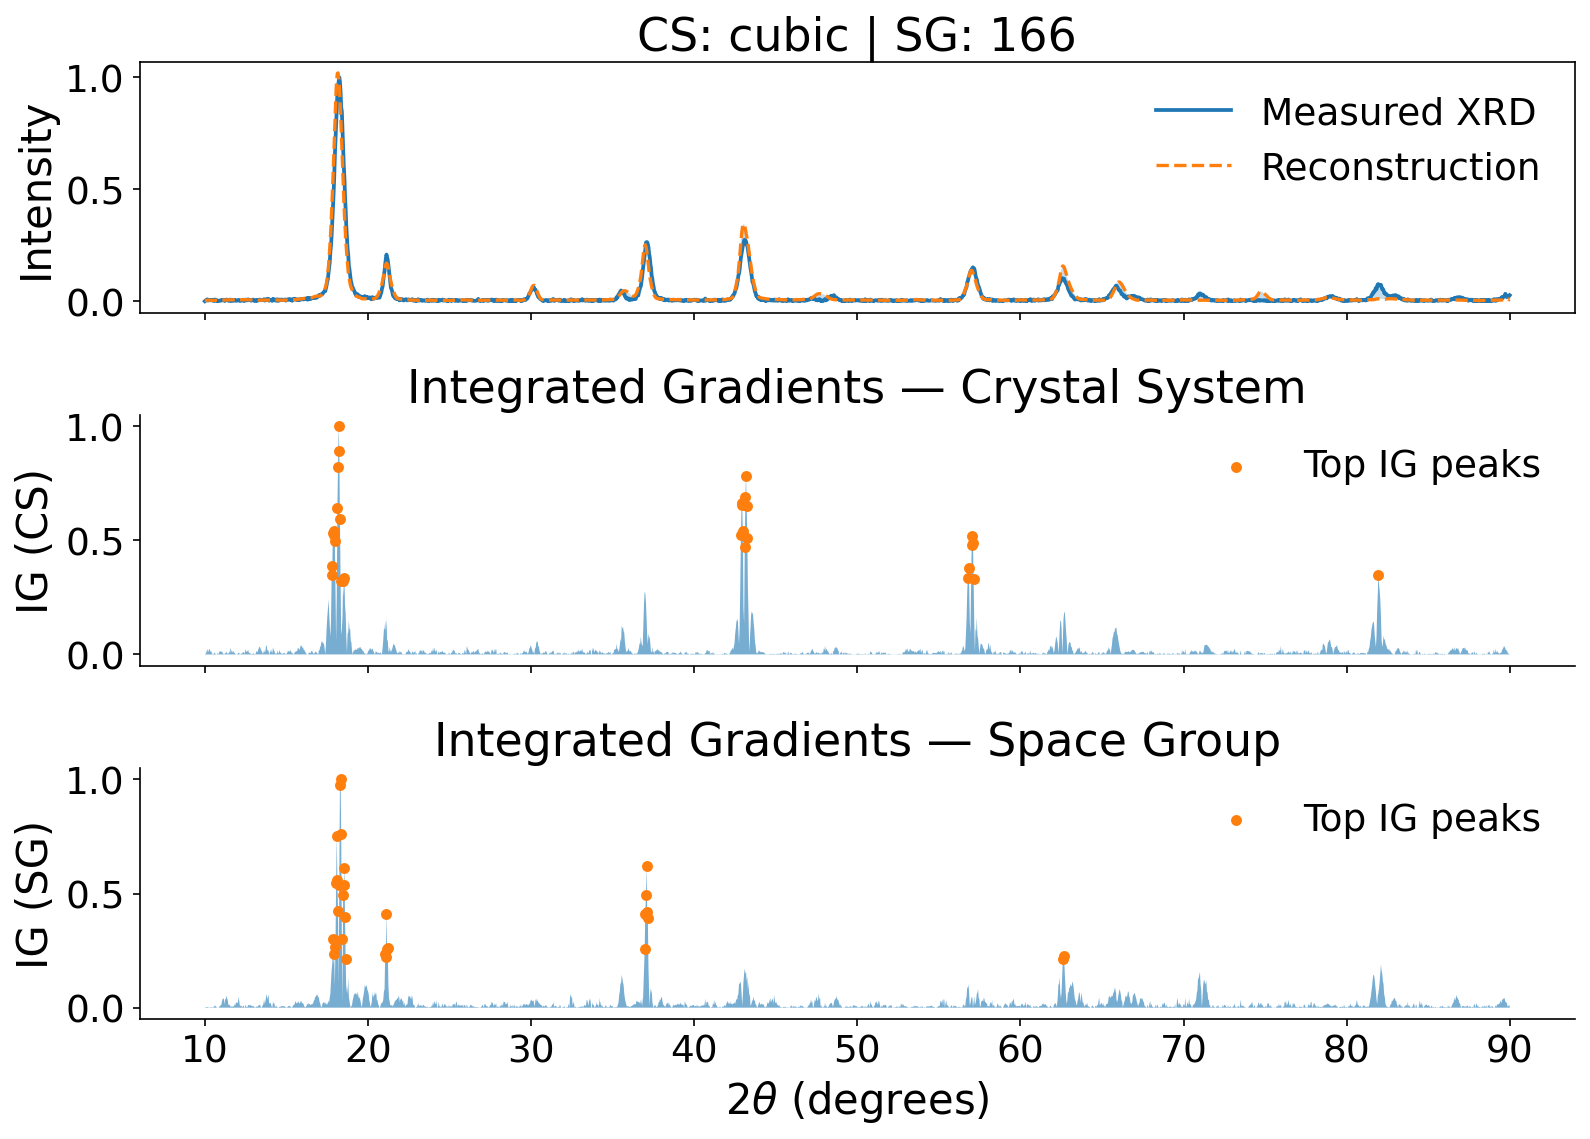

In [12]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.cuda.empty_cache()
# --------------------------------------------------
# Crystal-system classes
# --------------------------------------------------

cs_class_names = [
    "triclinic","monoclinic","orthorhombic",
    "tetragonal","trigonal","hexagonal","cubic"
]

CS_CLASS_TO_IDX = {c: i for i, c in enumerate(cs_class_names)}


# --------------------------------------------------
# Space-group classes (model classes)
# --------------------------------------------------

sg_class_names = [
    1, 2, 8, 11, 12, 14, 15, 19,
    38, 61, 62, 63, 71, 123, 139,
    166, 187, 194, 216, 221, 225, 227
]

SG_CLASS_TO_IDX = {int(sg): i for i, sg in enumerate(sg_class_names)}
SG_CLASS_TO_IDX.update({str(int(sg)): i for i, sg in enumerate(sg_class_names)})


# --------------------------------------------------
# Load Train Latents
# --------------------------------------------------

train_path_cs = os.path.join(CS_LATENT, "xrd_train_latents.npz")
train_data_cs = np.load(train_path_cs, allow_pickle=True)

train_latents_cs = train_data_cs["latents"]
train_labels_cs  = train_data_cs["labels"]


train_path_sg = os.path.join(SG_LATENT, "xrd_train_latents_sg.npz")
train_data_sg = np.load(train_path_sg, allow_pickle=True)

train_latents_sg = train_data_sg["latents"]
train_labels_sg  = train_data_sg["labels"]


# --------------------------------------------------
# Normalize latent vectors
# --------------------------------------------------

def normalize_vectors(vectors):

    return vectors / np.clip(
        norm(vectors, axis=1, keepdims=True),
        1e-12,
        None
    )

train_norm_cs = normalize_vectors(train_latents_cs)
train_norm_sg = normalize_vectors(train_latents_sg)
# --------------------------------------------------
# Load FULL IG DATABASE (CPU)
# --------------------------------------------------

def load_ig_db(h5_path):

    with h5py.File(h5_path, "r") as f:
        ig = f["attributions"][:]      
        y  = f["true_classes"][:]

    ig = np.abs(ig).astype(np.float32)
    ig /= (np.linalg.norm(ig, axis=1, keepdims=True) + 1e-8)

    train_igs_torch = torch.tensor(
        ig,
        dtype=torch.float32,
        device="cpu"
    )

    train_labels_torch = torch.tensor(
        y,
        dtype=torch.long,
        device="cpu"
    )

    return train_igs_torch, train_labels_torch


print("Loading IG database...")

train_igs_torch_cs, train_ig_labels_torch_cs = load_ig_db(
    IG_database_CS
)

train_igs_torch_sg, train_ig_labels_torch_sg = load_ig_db(
    IG_database_SG
)

print("IG database loaded.")


# --------------------------------------------------
# Load External Dataset
# --------------------------------------------------

with h5py.File(external_test_ruff_dataset, "r") as f:

    x_test = f["xrd"][:]
    crystal_systems = f["crystalsystems"][:]
    space_groups = f["labels"][:]      # SG numbers
    xaxis = f["xaxis"][:]
    compositions = f["compositions"][:]


# --------------------------------------------------
# Decode strings
# --------------------------------------------------

crystal_systems = [
    cs.decode() if isinstance(cs, bytes) else cs
    for cs in crystal_systems
]

compositions = [
    c.decode() if isinstance(c, bytes) else c
    for c in compositions
]


# --------------------------------------------------
# Filter dataset to only SG classes used in training
# --------------------------------------------------

mask = np.isin(space_groups, sg_class_names)

x_test = x_test[mask]
crystal_systems = np.array(crystal_systems)[mask]
compositions = np.array(compositions)[mask]
space_groups = space_groups[mask]

print("Filtered dataset size:", len(x_test))
print("Available SG classes:", np.unique(space_groups))


# --------------------------------------------------
# Select Sample
# --------------------------------------------------

sample_index = 260

sample_composition = compositions[sample_index]

true_cs = crystal_systems[sample_index]
true_sg = space_groups[sample_index]

x_sample_np = x_test[sample_index]


# --------------------------------------------------
# Convert to Torch Tensor
# --------------------------------------------------

x_sample = torch.tensor(
    x_sample_np,
    dtype=torch.float32,
    device=device
).unsqueeze(0)


# --------------------------------------------------
# Run Hybrid Inference
# --------------------------------------------------

res = infer_cs_and_sg_once(
    # CS
    model_cls_cs=model_cls_cs,
    train_norm_cs=train_norm_cs,
    train_labels_cs=train_labels_cs,
    train_igs_torch_cs=train_igs_torch_cs,
    train_ig_labels_torch_cs=train_ig_labels_torch_cs,
    cs_class_names=cs_class_names,
    cs_class_to_idx=CS_CLASS_TO_IDX,

    # SG
    model_cls_sg=model_cls_sg,
    train_norm_sg=train_norm_sg,
    train_labels_sg=train_labels_sg,
    train_igs_torch_sg=train_igs_torch_sg,
    train_ig_labels_torch_sg=train_ig_labels_torch_sg,
    sg_class_names=sg_class_names,
    sg_class_to_idx=SG_CLASS_TO_IDX,

    # shared
    recon_model=model_rec_sg,
    x=x_sample,
    device=device,

    composition=sample_composition,
    search_engine=search_engine,

    do_plot=True
)


In [13]:
print_representative_output(
    res,
    cs_class_names,
    sg_class_names,
    true_cs=true_cs,
    true_sg=true_sg
)


Representative inference output
True: CS = cubic, SG = 225
----------------------------------------------------------------------

Crystal System (CS)
----------------------------------------
Final:       cubic
Model:       cubic (0.99995)
Retrieval:   trigonal (1.00000)
IG:          triclinic (1.00000)
Composition: orthorhombic

Space Group (SG)
----------------------------------------
Final:       166
Model:       1 (0.52860)
Retrieval:   166 (1.00000)
IG:          1 (1.00000)
Composition: 62

Additional signals
----------------------------------------
Reconstruction error: 3.78e-04

Top-k candidates (probability / similarity)

Crystal System – IG
 1. triclinic       1.00000
 2. monoclinic      4.09e-22
 3. orthorhombic    0.00e+00

Crystal System – Retrieval
 1. trigonal        1.00000
 2. cubic           1.24e-72

Crystal System – Composition
 1. tetragonal      0.40000
 2. orthorhombic    0.40000
 3. trigonal        0.20000

Space Group – IG
 1. SG 1     1.00000
 2. SG 14    0.00

In [16]:
# =========================================
# Accuracy Counters
# =========================================

cs_model_correct = 0
cs_retr_correct = 0
cs_ig_correct = 0
cs_comp_correct = 0
cs_hybrid_correct = 0

sg_model_correct = 0
sg_retr_correct = 0
sg_ig_correct = 0
sg_comp_correct = 0
sg_hybrid_correct = 0

total = len(x_test)

print("Evaluating", total, "samples")


# =========================================
# Evaluation Loop
# =========================================

for i in range(total):

    x_sample = torch.tensor(
        x_test[i],
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    sample_composition = compositions[i]

    # -------------------------
    # True labels
    # -------------------------

    true_cs = crystal_systems[i]
    true_cs_idx = CS_CLASS_TO_IDX[true_cs]

    true_sg = int(space_groups[i])
    true_sg_idx = SG_CLASS_TO_IDX[true_sg]


    # -------------------------
    # Run inference
    # -------------------------

    res = infer_cs_and_sg_once(

        # CS
        model_cls_cs=model_cls_cs,
        train_norm_cs=train_norm_cs,
        train_labels_cs=train_labels_cs,
        train_igs_torch_cs=train_igs_torch_cs,
        train_ig_labels_torch_cs=train_ig_labels_torch_cs,
        cs_class_names=cs_class_names,
        cs_class_to_idx=CS_CLASS_TO_IDX,

        # SG
        model_cls_sg=model_cls_sg,
        train_norm_sg=train_norm_sg,
        train_labels_sg=train_labels_sg,
        train_igs_torch_sg=train_igs_torch_sg,
        train_ig_labels_torch_sg=train_ig_labels_torch_sg,
        sg_class_names=sg_class_names,
        sg_class_to_idx=SG_CLASS_TO_IDX,

        # shared
        recon_model=model_rec_sg,
        x=x_sample,
        device=device,

        composition=sample_composition,
        search_engine=search_engine,

        do_plot=False
    )


    # =========================================
    # CRYSTAL SYSTEM
    # =========================================

    cs = res["cs"]

    if cs["model_pred"] == true_cs_idx:
        cs_model_correct += 1

    if cs["retrieval_pred"] == true_cs_idx:
        cs_retr_correct += 1

    if cs["ig_pred"] is not None and cs["ig_pred"] == true_cs_idx:
        cs_ig_correct += 1

    if res["composition"]["cs_pred"] is not None and res["composition"]["cs_pred"] == true_cs_idx:
        cs_comp_correct += 1

    if cs["final_pred"] == true_cs_idx:
        cs_hybrid_correct += 1


    # =========================================
    # SPACE GROUP
    # =========================================

    sg = res["sg"]

    if sg["model_pred"] == true_sg_idx:
        sg_model_correct += 1

    if sg["retrieval_pred"] == true_sg_idx:
        sg_retr_correct += 1

    if sg["ig_pred"] is not None and sg["ig_pred"] == true_sg_idx:
        sg_ig_correct += 1

    # composition SG prediction
    comp_sg = res["composition"]["sg_number"]

    if comp_sg is not None and int(comp_sg) == true_sg:
        sg_comp_correct += 1

    if sg["final_pred"] == true_sg_idx:
        sg_hybrid_correct += 1


    if i % 50 == 0:
        print(f"Processed {i}/{total}")

Evaluating 750 samples
Processed 0/750
Processed 50/750
Processed 100/750
Processed 150/750
Processed 200/750
Processed 250/750
Processed 300/750
Processed 350/750
Processed 400/750
Processed 450/750
Processed 500/750
Processed 550/750
Processed 600/750
Processed 650/750
Processed 700/750


In [17]:
print("\n==============================")
print("Total samples:", total)

print("\n------ CRYSTAL SYSTEM ------")
print("Model:", cs_model_correct / total)
print("Retrieval:", cs_retr_correct / total)
print("IG:", cs_ig_correct / total)
print("Composition:", cs_comp_correct / total)
print("Hybrid:", cs_hybrid_correct / total)

print("\n------ SPACE GROUP ------")
print("Model:", sg_model_correct / total)
print("Retrieval:", sg_retr_correct / total)
print("IG:", sg_ig_correct / total)
print("Composition:", sg_comp_correct / total)
print("Hybrid:", sg_hybrid_correct / total)

print("==============================")


Total samples: 750

------ CRYSTAL SYSTEM ------
Model: 0.7613333333333333
Retrieval: 0.7813333333333333
IG: 0.5293333333333333
Composition: 0.32
Hybrid: 0.8106666666666666

------ SPACE GROUP ------
Model: 0.508
Retrieval: 0.5666666666666667
IG: 0.168
Composition: 0.22
Hybrid: 0.5613333333333334
